<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/5.0%20Churn_Model_Selection%20and%20Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install boto3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 9.5 MB/s eta 0:00:00


In [3]:
import boto3
import sys
import os
import importlib
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, inspect, text
from google.colab import userdata

from datetime import datetime


bucket_name = 'sales-data-analytics-portfolio-2026'

s3 = boto3.client(
    "s3",
    aws_access_key_id = userdata.get('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key   = userdata.get('AWS_SECRET_ACCESS_KEY'),
    region_name = 'eu-north-1'
)

s3.download_file(bucket_name, 'functions/segmentation_features.py','segmentation_features.py')
print('\nSuccessfully downloaded segmentation features function from Amazon Web Services')

sys.path.append(os.getcwd())
import segmentation_features
importlib.reload(segmentation_features)
from segmentation_features import segmentation_features

s3.download_file(bucket_name, "predictive_models/kmeans_segmentation.joblib", "kmeans_segmentation.joblib")

# For consistency, joblib file is pulled back to predict clusters
loaded_model = joblib.load("kmeans_segmentation.joblib")

s3.download_file(bucket_name, 'functions/feature_engineering.py', 'feature_engineering.py')

sys.path.append(os.getcwd())
import feature_engineering
importlib.reload(feature_engineering)
from feature_engineering import feature_engineering

s3.download_file(bucket_name, 'functions/churn_label_assignment.py', 'churn_label_assignment.py')

sys.path.append(os.getcwd())
import churn_label_assignment
importlib.reload(churn_label_assignment)
from churn_label_assignment import churn_label_assignment


engine = create_engine(userdata.get("NEON_DATABASE_URL"))

query = """
SELECT *
FROM v_clean_sales_analytics
"""

df = pd.read_sql(text(query), con = engine).dropna()

cutoff_date = '2011-08-31'
cutoff_date = pd.to_datetime(cutoff_date)

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Calculating features of data before cutoff_date
data = feature_engineering(df[df["InvoiceDate"] < cutoff_date])
data['KSegment'] = loaded_model.predict(segmentation_features(data).drop("CustomerID", axis = 1))
data['KSegment'] = data['KSegment'].astype('str')

data1 = churn_label_assignment(df)

df = data.merge(data1, how = 'left', on = "CustomerID")

print(df.isna().sum())
df.head()


Successfully downloaded segmentation features function from Amazon Web Services


/content/feature_engineering.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])



Churn labels for transactions before 2011-08-31
CustomerID                 0
Frequency                  0
ProductDiversity           0
AvgUnitPrice               0
AvgQuantity                0
AOV                        0
TotalRevenue               0
CohortMonth                0
Recency                    0
Tenure                     0
ObservedLifeSpan           0
RecencyToTenure            0
ActivePurchaseDensity      0
LifetimePurchaseDensity    0
ActiveMRate                0
LifetimeMRate              0
AvgIPI                     0
RelativeSilence            0
KSegment                   0
Churned                    0
dtype: int64


,CustomerID,Frequency,ProductDiversity,AvgUnitPrice,AvgQuantity,AOV,TotalRevenue,CohortMonth,Recency,Tenure,ObservedLifeSpan,RecencyToTenure,ActivePurchaseDensity,LifetimePurchaseDensity,ActiveMRate,LifetimeMRate,AvgIPI,RelativeSilence,KSegment,Churned
0,12346.0,1,1,1.040000,74215.000000,77183.600000,77183.60,2011-01,225,225,1,1.000000,1.000000,0.004444,77183.600000,343.038222,1.000000,225.000000,3,1
1,12347.0,5,82,2.797661,12.822581,22.506935,2790.86,2010-12,29,267,239,0.108614,0.020921,0.018727,11.677238,10.452659,48.600000,0.596708,3,0
2,12348.0,3,22,4.864643,75.857143,53.115714,1487.24,2010-12,148,258,111,0.573643,0.027027,0.011628,13.398559,5.764496,37.666667,3.929204,0,1
3,12350.0,1,17,3.841176,11.588235,19.670588,334.40,2011-02,210,210,1,1.000000,1.000000,0.004762,334.400000,1.592381,1.000000,210.000000,2,1
4,12352.0,4,26,27.449474,6.684211,41.100263,1561.81,2011-02,162,196,35,0.826531,0.114286,0.020408,44.623143,7.968418,9.500000,17.052632,2,1


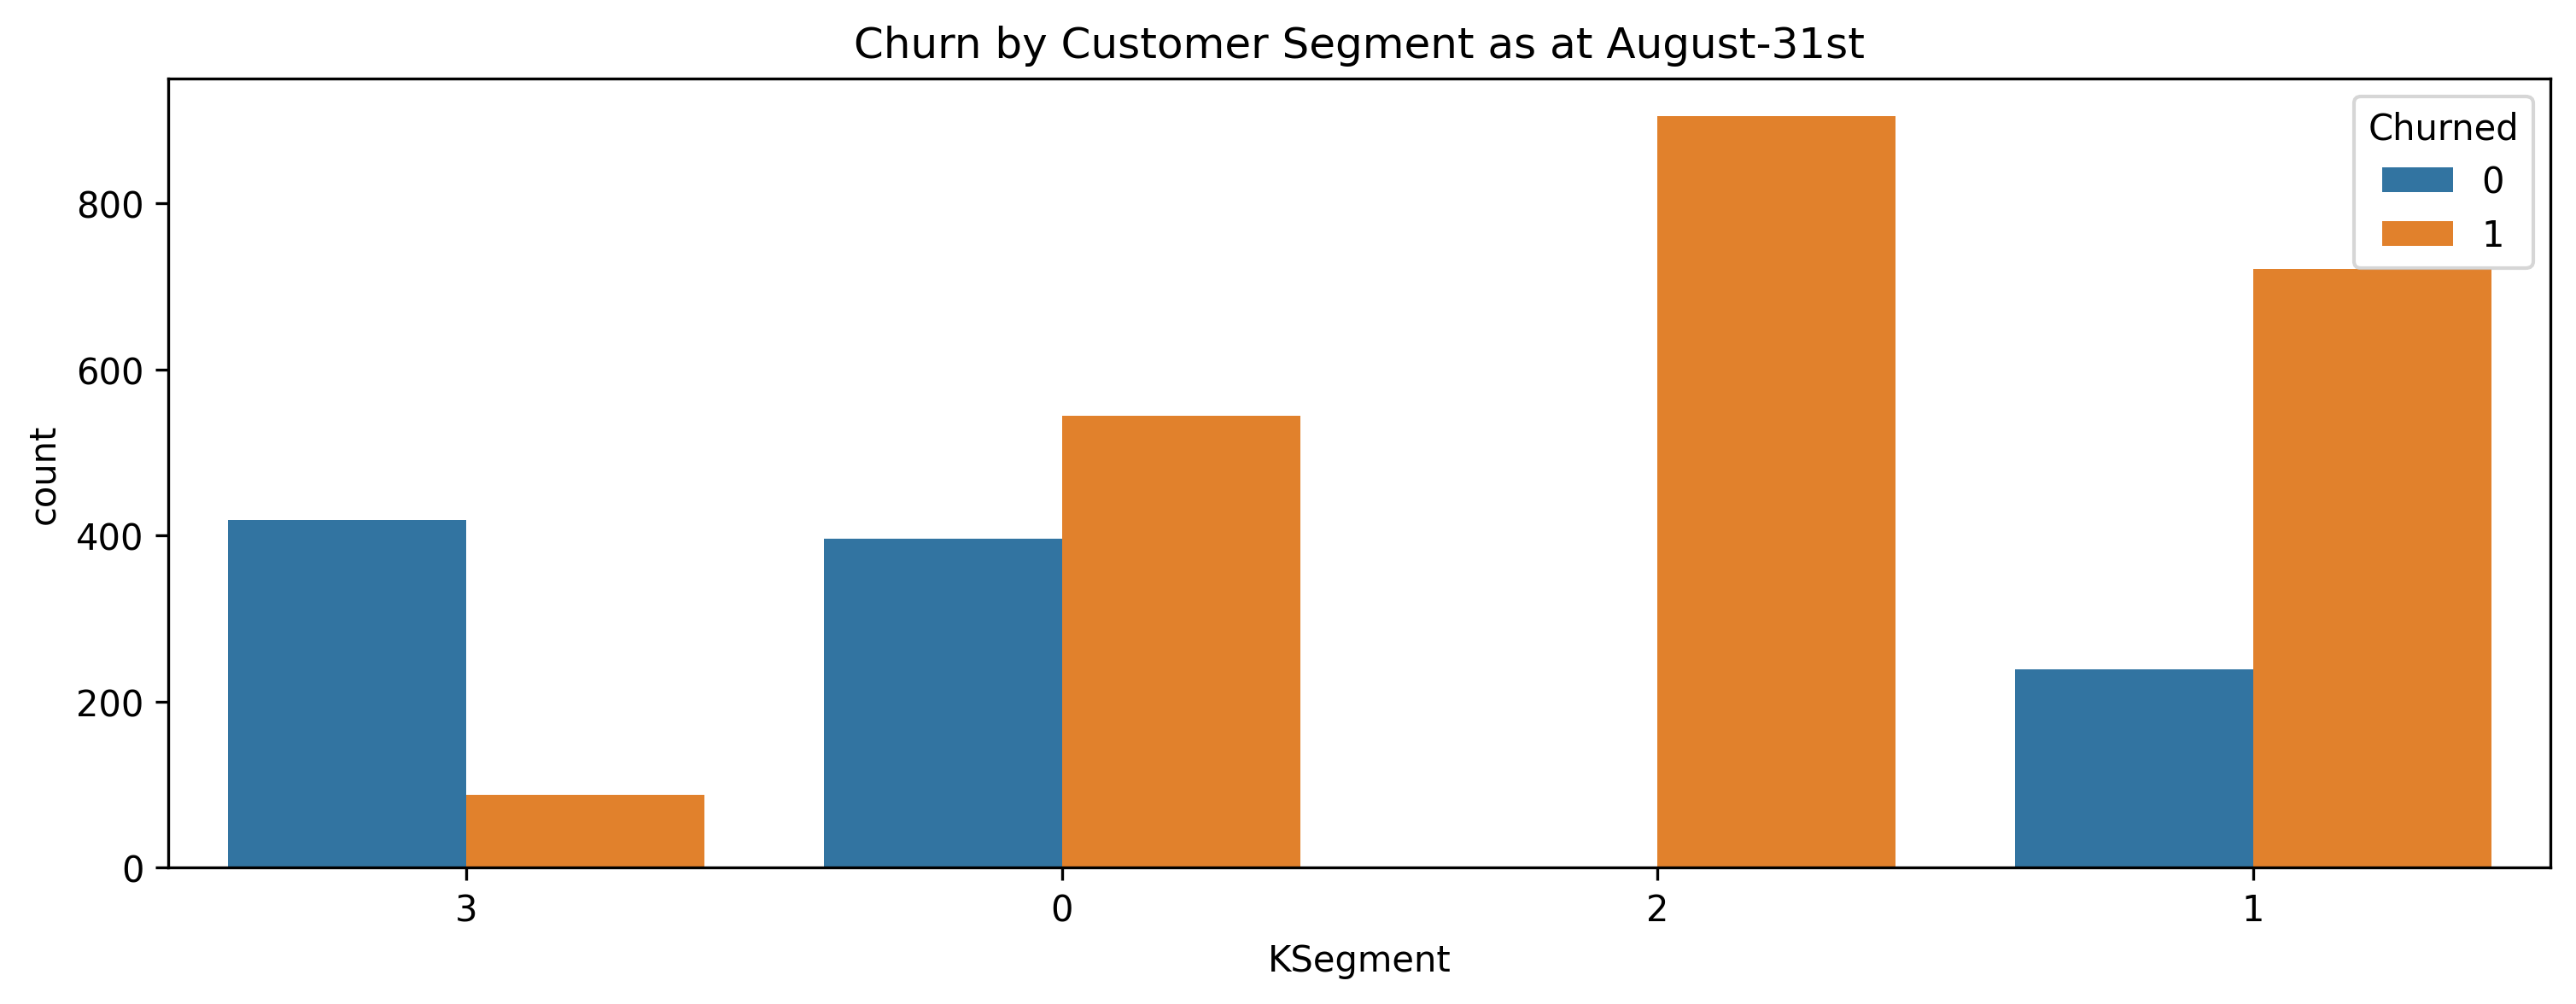

KSegment,0,1,2,3
Churned,,,,
0,396.000000,239.000000,0.0,419.00000
1,544.000000,721.000000,905.0,88.00000
ChurnRate,0.578723,0.751042,1.0,0.17357


In [4]:
plt.figure(figsize = (12,4), dpi = 300)
sns.countplot(data = df, x = 'KSegment', hue = 'Churned')
plt.title("Churn by Customer Segment as at August-31st")
plt.show()

summary = df.groupby(['KSegment', 'Churned']).size().unstack().fillna(0)
summary["ChurnRate"] = (summary[1]/(summary[0] + summary[1]))

summary.stack().unstack(level =0)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X = df.drop(['Churned', 'CustomerID', 'CohortMonth', 'KSegment'], axis = 1)
X = pd.get_dummies(X, drop_first = True)
features = X.columns
X = X

y = df['Churned']

customer_ids = df['CustomerID']

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(X, y, customer_ids, test_size=0.2, random_state = 42, stratify = y)

df_train, df_test = train_test_split(df['CustomerID'], test_size = 0.20, random_state = 42)

scaler = StandardScaler()

models = [("Logistic Regression", LogisticRegression(max_iter = 1000, class_weight = 'balanced')),
          ("Random Forest", RandomForestClassifier(random_state = 42, class_weight = 'balanced')),
          ("Decision Tree", DecisionTreeClassifier(random_state = 42, class_weight = 'balanced')),
          ("Xgboost", XGBClassifier(random_state = 42)),
          ("Lightgbm", LGBMClassifier(random_state = 42, class_weight = 'balanced', verbose = -1))]

model_name = []
accuracy_avg = []
precision_avg = []
recall_avg = []
for name, model in models:
  pipeline = make_pipeline(scaler, model)
  kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
  accuracy_scores = cross_val_score(pipeline, X_train, y_train, cv = kf, scoring = 'accuracy')
  precision_scores = cross_val_score(model, X_train, y_train, cv = kf, scoring = 'precision')
  recall_scores = cross_val_score(model, X_train, y_train, cv = kf, scoring = 'recall')

  model_name.append(name)
  accuracy_avg.append(accuracy_scores)
  precision_avg.append(precision_scores)
  recall_avg.append(recall_scores)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

/tmp/ipykernel_1473/1547363700.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(accuracy_avg, labels = model_name)
/tmp/ipykernel_1473/1547363700.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(precision_avg, labels = model_name)
/tmp/ipykernel_1473/1547363700.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(recall_avg, labels = model_name)


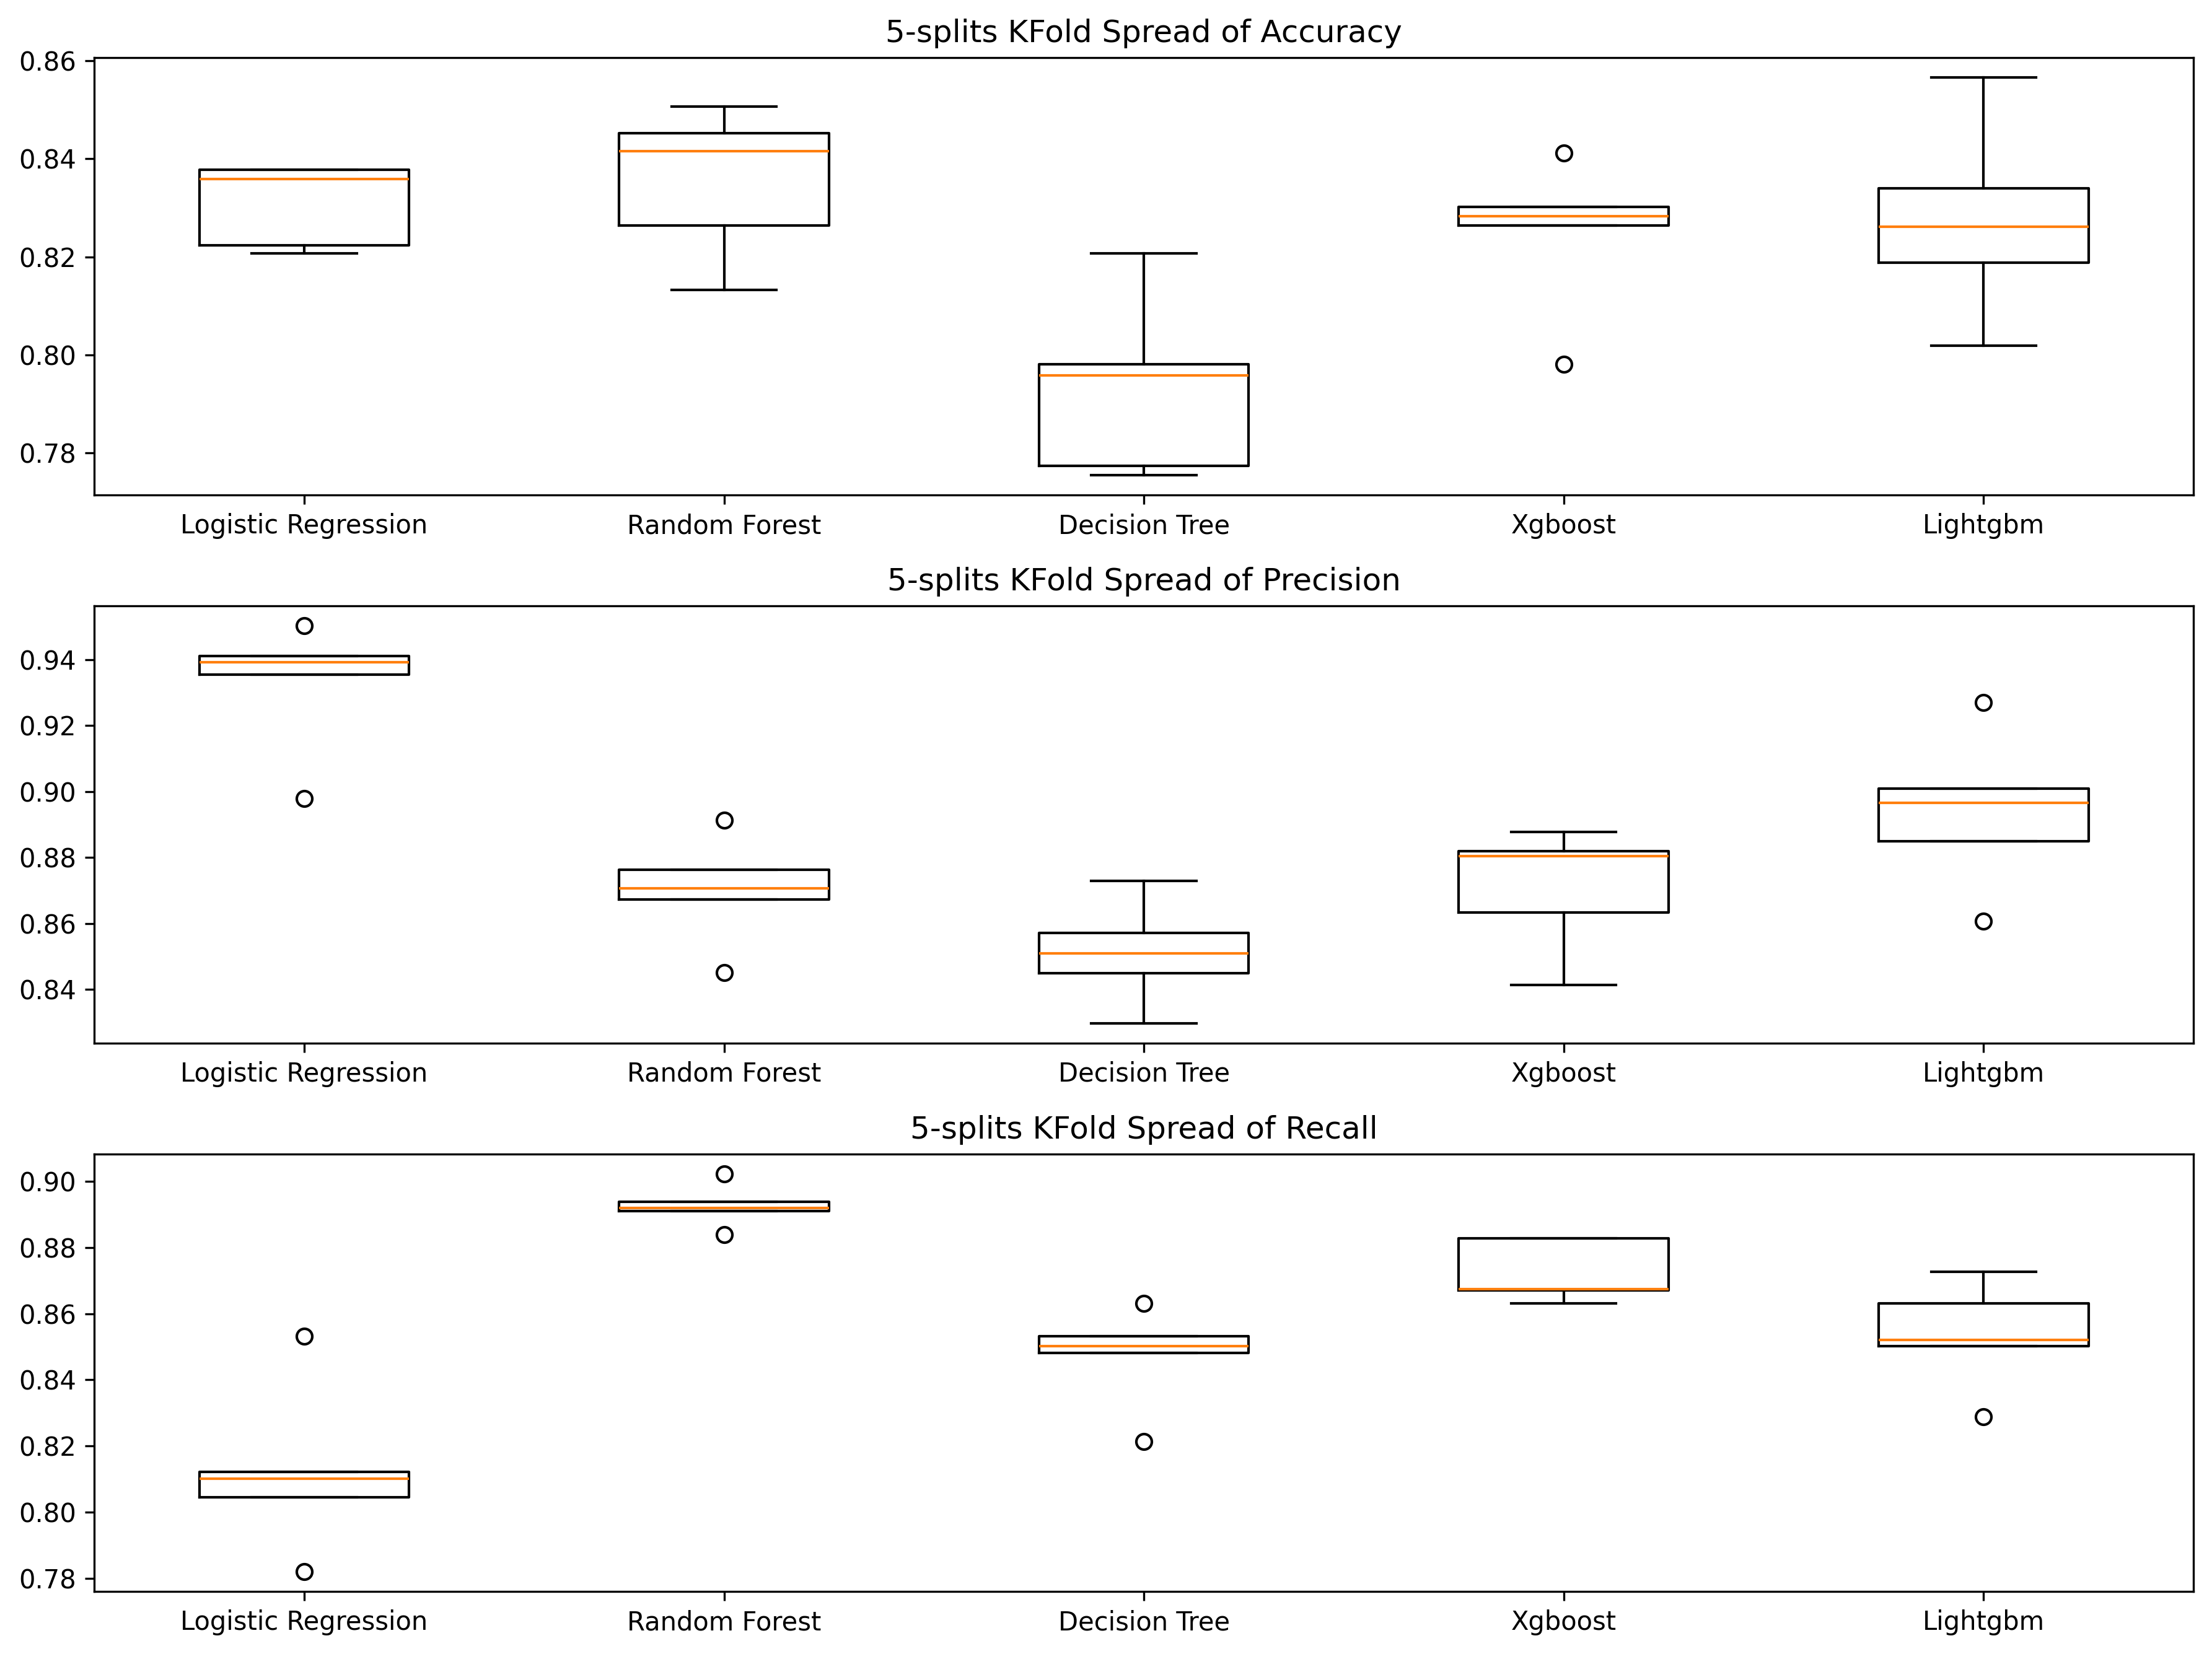

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize = (12,9), dpi = 300)
ax1.boxplot(accuracy_avg, labels = model_name)
ax1.set_title("5-splits KFold Spread of Accuracy")
ax2.boxplot(precision_avg, labels = model_name)
ax2.set_title("5-splits KFold Spread of Precision")
ax3.boxplot(recall_avg, labels = model_name)
ax3.set_title("5-splits KFold Spread of Recall")
plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully saved churn model to /content/drive/MyDrive/churn_model.joblib
Successfully loaded churn model from Google Drive


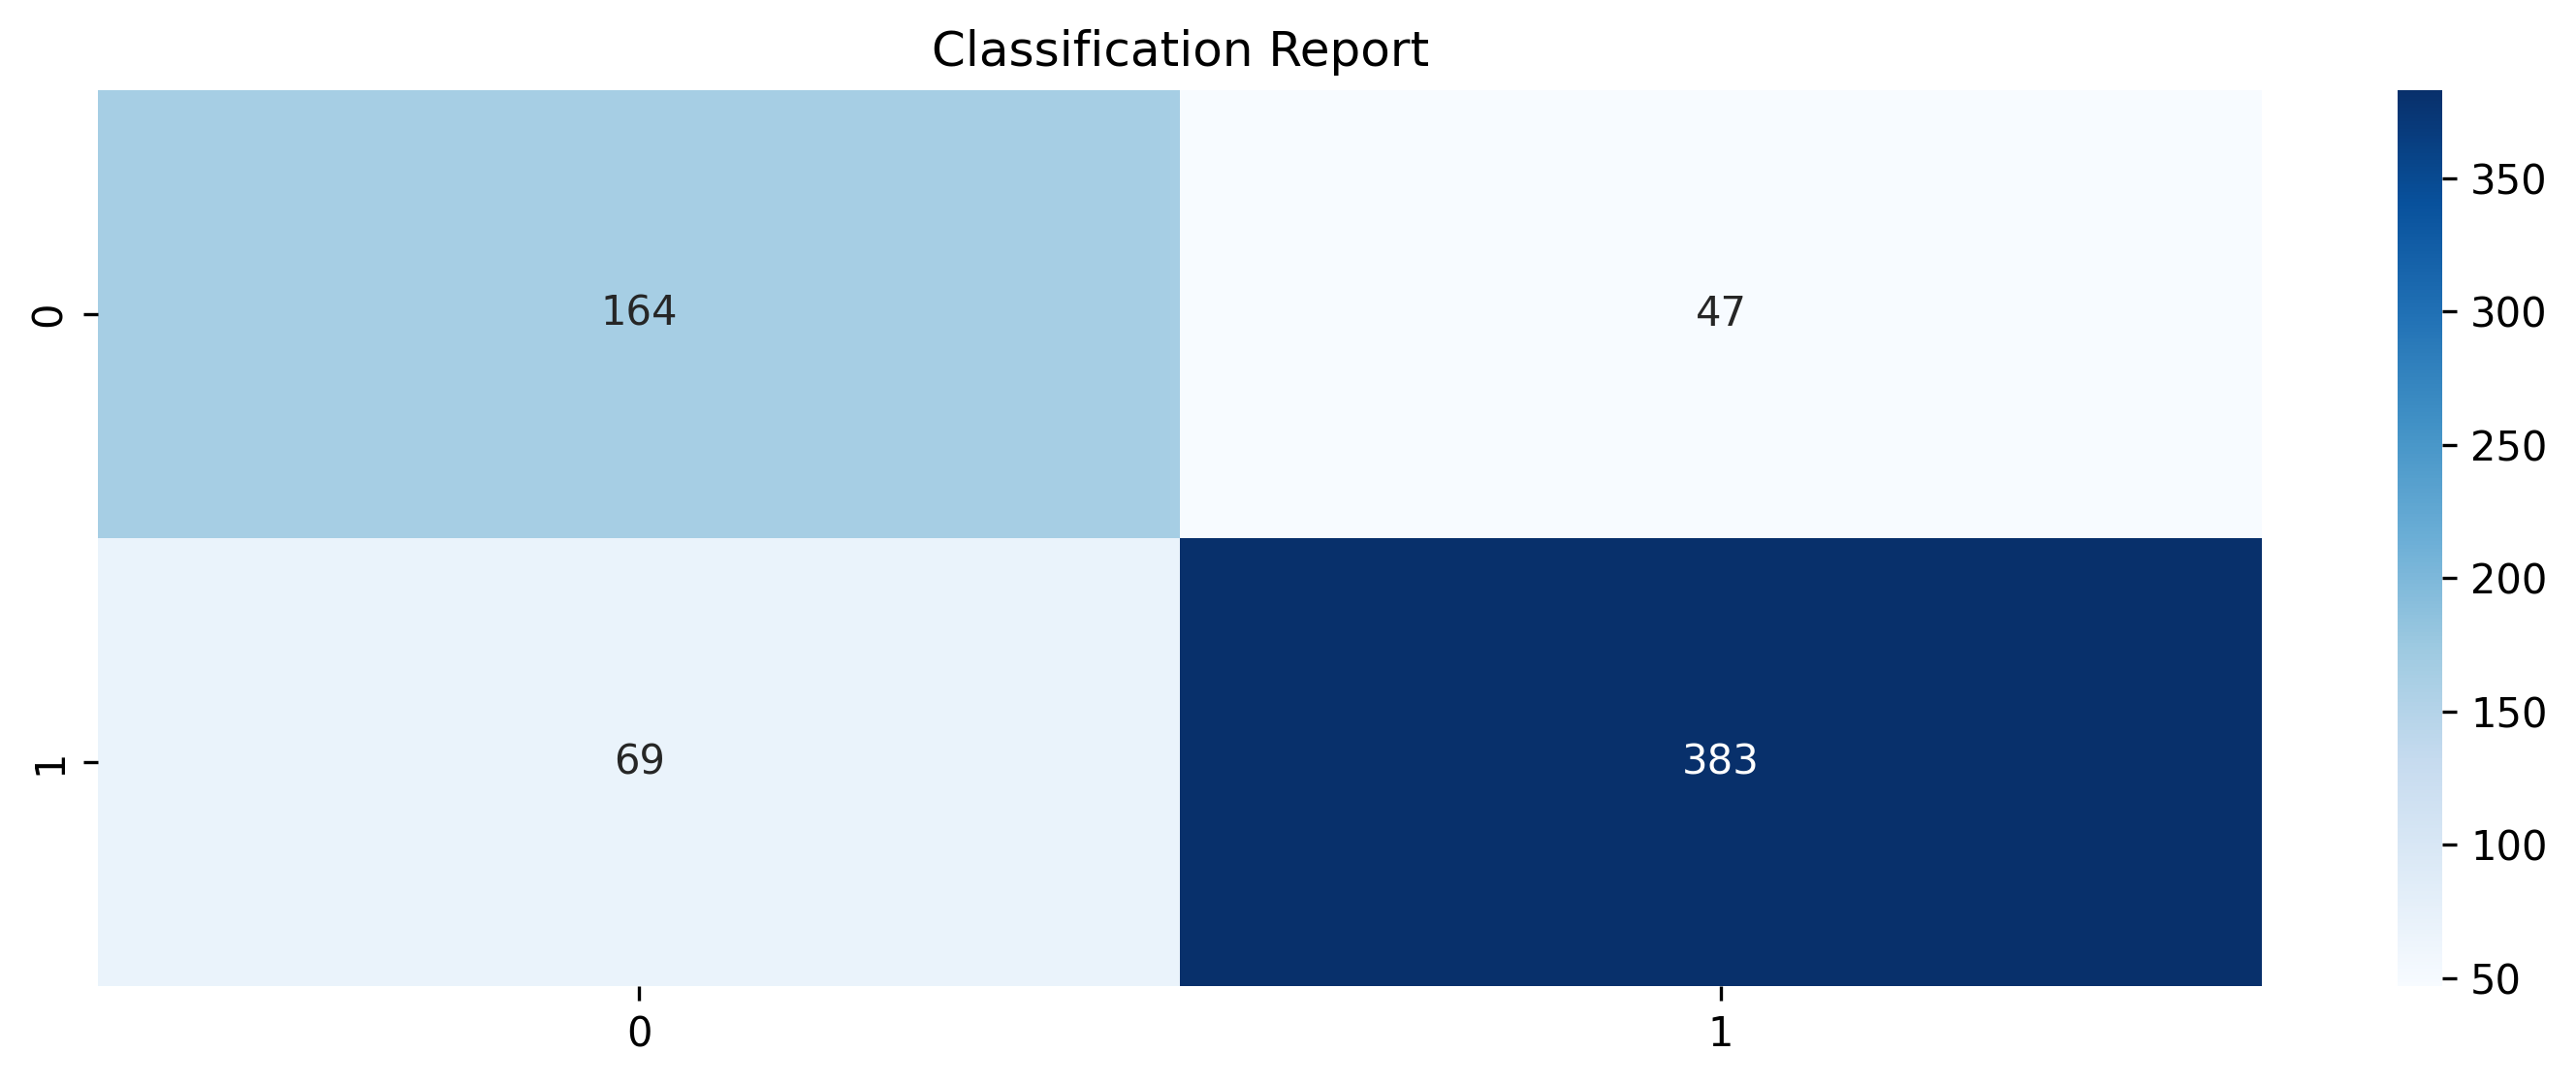

              precision    recall  f1-score   support

           0       0.70      0.78      0.74       211
           1       0.89      0.85      0.87       452

    accuracy                           0.83       663
   macro avg       0.80      0.81      0.80       663
weighted avg       0.83      0.83      0.83       663



In [12]:
from google.colab import drive
drive.mount('/content/drive')
import joblib

churn_model_path = '/content/drive/MyDrive/churn_model.joblib'

model = LogisticRegression(max_iter = 1000, class_weight = 'balanced')
model = RandomForestClassifier(n_estimators = 250, max_depth = 20, min_samples_leaf = 2, random_state = 42, class_weight = 'balanced')
pipeline = make_pipeline(scaler, model)
pipeline.fit(X_train, y_train)

joblib.dump(pipeline, churn_model_path)
print(f'Successfully saved churn model to {churn_model_path}')

loaded_model = joblib.load(churn_model_path)
print("Successfully loaded churn model from Google Drive")

y_pred = loaded_model.predict(X_test)
y_proba = loaded_model.predict_proba(X_test)[:,1]

c_matrix = confusion_matrix(y_test, y_pred)

# Creating predictions table in Database
pred_df = pd.DataFrame({
    "CustomerID" : ids_test,
    "ActualChurn": y_test,
    "PredictedProbability": y_proba,
    "PredictedLabel": y_pred
})

engine = create_engine(userdata.get('NEON_DATABASE_URL'))
#Creating Table of Predictions in Database
pred_df.to_sql(
    name = 'churn_test_predictions',
    con = engine,
    if_exists = 'replace',
    index = False
)

plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(c_matrix, cmap='Blues', annot = True, fmt = 'g')
plt.title("Classification Report")
plt.show()

print(classification_report(y_test, y_pred))

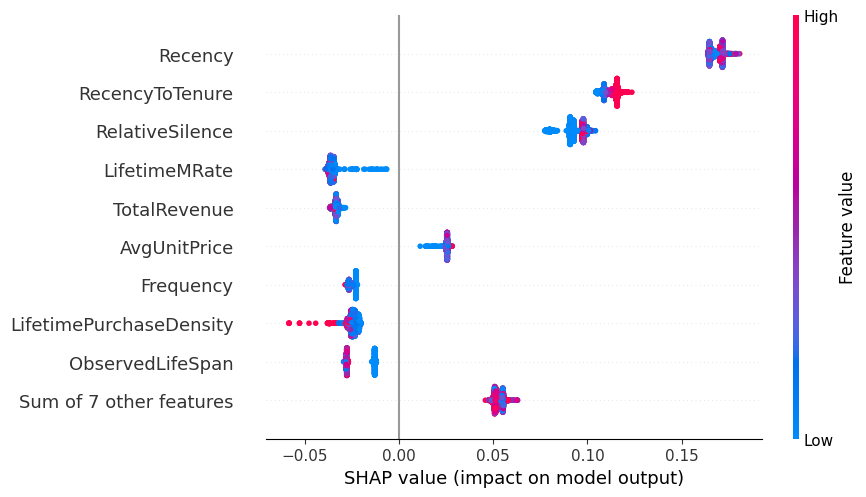

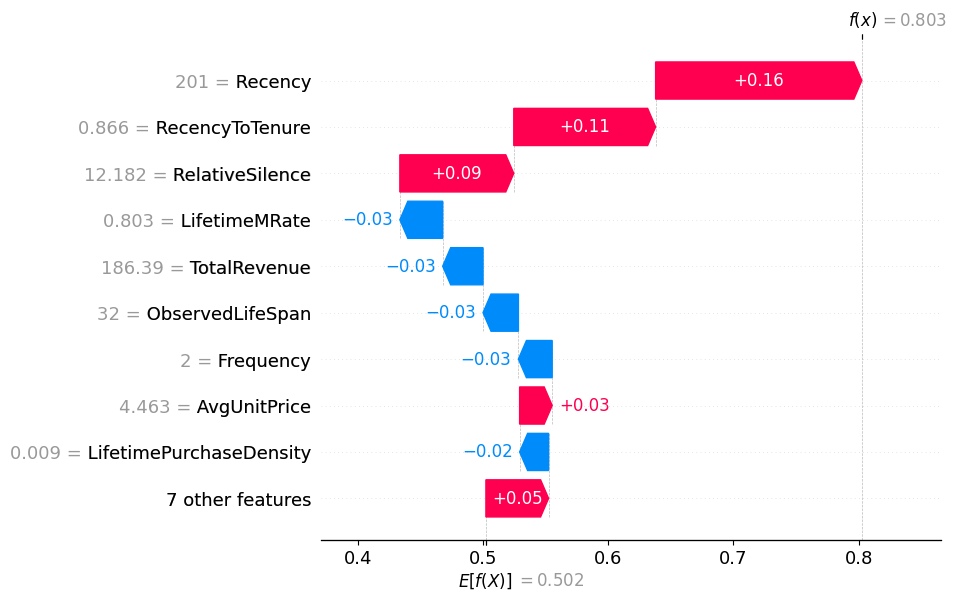

In [22]:

import matplotlib.pyplot as plt
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)  # or X_test

shap_values_class1 = shap_values[:, :, 1]

shap.plots.beeswarm(shap_values_class1, max_display=10)

plt.clf()

shap.plots.waterfall(shap_values_class1[0], max_display=10)